In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
train = pd.read_csv('/kaggle/input/sporify-songs/train.csv', index_col=0)
train.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity
0,0.00948,67.237,0.188,wellness,-37.230,0.1090,0.0738,Burgundy Skies,4.0,0.0376,...,3vdgwvyYVubJFTIwDjSQmy,0.0,7.0,151340.0,0.9710,3VvomBh2ZKssj7gDFZF8gI,yoga,audio_features,37i9dQZF1DX9uKNf5jGX6m,46
1,0.41300,94.938,0.494,pop,-10.432,0.1930,0.2730,Gigi Perez,4.0,0.0254,...,68CN2LzY8MoxO2udy2C22e,1.0,11.0,211979.0,0.6820,2262bWmqomIaJXwCRHr13j,global,audio_features,37i9dQZEVXbMDoHDwVN2tF,93
2,0.38600,142.127,0.519,world,-12.732,0.3750,0.3130,Yume.Play,4.0,0.0375,...,7dHB1w2uCRZEQuhl7KnYSi,0.0,3.0,124620.0,0.6800,5p3sftlIikSxTSX88EVTF1,chinese,audio_features,26xHk0w8Kpcq3eSBjmnAmu,34
3,0.89800,132.027,0.779,gospel,-4.589,0.1820,0.6750,Olamilekan Akamo,4.0,0.0850,...,4LmzdtwhZqntC6vMAW8RgJ,1.0,8.0,1034000.0,0.0220,00DPAwQ3NkWs6PZKNxy7Pi,modern,audio_features,4reKL9y3Zh2ccRcBKfAwuz,30
4,0.40900,170.071,0.714,electronic,-6.476,0.0883,0.4970,Dele GT,4.0,0.0787,...,2xX51dQjNlCurApWTRzNcU,1.0,0.0,136324.0,0.0821,0KDGlg4LGADUYd9pyI6gVm,french,audio_features,58zteW83Lvl8e158fCCFVN,17


In [3]:
test = pd.read_csv('/kaggle/input/sporify-songs/test.csv')
test.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.530,122.949,0.727,hip-hop,-9.169,0.1010,0.444,"Green Montana, SDM",4.0,0.3090,...,0.000392,5ORwfRIZBQiJ1dQ2cQDIFO,0.0,0.0,172280.0,0.434000,0ex0EZnrO2mMPIkYp3ewZX,french,audio_features,6OYaw7arTfoGEHpGdItkLQ
1,0.668,90.969,0.646,pop,-5.203,0.2120,0.640,Mark Ambor,4.0,0.0282,...,0.000000,3PlCMwyq6nuQYtoYproV1o,1.0,2.0,148318.0,0.491000,5uQ7de4EWjb3rkcFxyEOpu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.974,150.008,0.495,electronic,-2.801,0.3690,0.316,"Age Of Love, Brennan Heart, ANDY SVGE",4.0,0.0642,...,0.000001,4pk35uSAFZ7Q2MweAdCWN3,1.0,1.0,187200.0,0.000396,4h1igBodAXxo1IKsbV5h4Q,hardstyle,audio_features,37i9dQZF1DX0pH2SQMRXnC
3,0.668,150.043,0.773,world,-4.254,0.0763,0.741,"Nicki Nicole, Dread Mar I, Bizarrap",4.0,0.3660,...,0.000000,3NXbwVxHga0cmLdnRIDX64,0.0,4.0,157419.0,0.374000,2mMZAd3ol9wGI2WJl4XJCF,throat singing,audio_features,37i9dQZF1DWZKxXtx1tSxF
4,0.605,109.986,0.769,ambient,-8.490,0.1200,0.674,"M.anifest, The Cavemen., Flea",4.0,0.0725,...,0.000000,31PqWyE2sNdjg83d5YKIhm,1.0,0.0,164182.0,0.501000,6NMuQPXrTjnolGuttpu5Xy,meditative,audio_features,3kEpLybbAlVUVimW5Evijb


# **EDA + предобработка** 

**Тут я просто крутил данные, в целом — ничего интересного.**

In [4]:
train.dtypes

energy                      float64
tempo                       float64
danceability                float64
playlist_genre               object
loudness                    float64
liveness                    float64
valence                     float64
track_artist                 object
time_signature              float64
speechiness                 float64
track_href                   object
uri                          object
track_album_name             object
playlist_name                object
analysis_url                 object
track_id                     object
track_name                   object
track_album_release_date     object
instrumentalness            float64
track_album_id               object
mode                        float64
key                         float64
duration_ms                 float64
acousticness                float64
id                           object
playlist_subgenre            object
type                         object
playlist_id                 

In [5]:
train.shape[0]

3623

In [6]:
len(set(train['id']) & set(test['id']))

124

In [7]:
pd.DataFrame(train.groupby(['track_id', 'track_name'])['popularity'].count()).query('popularity > 1')

,,popularity
track_id,track_name,
03xIKiQXopptD4Sv8ijvcG,2 Times,2
05RgAMGypEvqhNs5hPCbMS,Panama - 2015 Remaster,2
0D9JNf7ntudlGuRUQW1bXp,Gratitude,2
0DiWol3AO6WpXZgp0goxAV,One More Time,2
0GONea6G2XdnHWjNZd6zt3,Summer Of '69,2
...,...,...
7qiZfU4dY1lWllzX7mPBI3,Shape of You,2
7rIHP8C7oHYONnJpLjVnAc,Many Things,2
7txxAtOMwLLnQTpKeBL6bp,Mother,2


**Тут я проверял, что у одного трека одинаковая популярность.**

In [8]:
train.query('track_id == "03xIKiQXopptD4Sv8ijvcG"')

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity
130,0.951,74.973,0.772,electronic,-3.375,0.036,0.4,"Dimitri Vegas, Steve Aoki, Ann Lee, Sound Of L...",4.0,0.271,...,4wiZ07TwRSwCUTjIXqcriy,0.0,9.0,152000.0,0.0634,03xIKiQXopptD4Sv8ijvcG,techno,audio_features,37i9dQZF1DX4uPi2roRUwU,68
1829,0.951,74.973,0.772,electronic,-3.375,0.036,0.4,"Dimitri Vegas, Steve Aoki, Ann Lee, Sound Of L...",4.0,0.271,...,4wiZ07TwRSwCUTjIXqcriy,0.0,9.0,152000.0,0.0634,03xIKiQXopptD4Sv8ijvcG,techno,audio_features,37i9dQZF1DX4uPi2roRUwU,68


In [9]:
train.drop_duplicates().shape[0]

3603

**Судя по всему, в данных есть дубликаты — выкину их, чтобы уменьшить переобучение.**

In [10]:
train.nunique()

energy                      1020
tempo                       3171
danceability                 767
playlist_genre                35
loudness                    2970
liveness                     895
valence                     1073
track_artist                2684
time_signature                 4
speechiness                  968
track_href                  3426
uri                         3426
track_album_name            2961
playlist_name                116
analysis_url                3426
track_id                    3427
track_name                  3348
track_album_release_date    1567
instrumentalness            1561
track_album_id              3000
mode                           2
key                           12
duration_ms                 3208
acousticness                1616
id                          3426
playlist_subgenre             84
type                           1
playlist_id                  115
popularity                    86
dtype: int64

'type' выкидываем, так как константный признак

In [11]:
train[['playlist_id', 'playlist_name']].nunique()

playlist_id      115
playlist_name    116
dtype: int64

In [12]:
train[['playlist_id', 'playlist_name']].drop_duplicates().groupby(['playlist_id']).count().query('playlist_name > 1')

,playlist_name
playlist_id,
37i9dQZF1DWWOaP4H0w5b0,2


In [13]:
train.query('playlist_id == "37i9dQZF1DWWOaP4H0w5b0"')['playlist_name'].unique()

array(['Death Metal Essentials', 'Metal Essentials'], dtype=object)

Судя по всему, можно удалить айдишники плейлистов без потери информации

In [14]:
train[['track_href', 'uri', 'track_id', 'analysis_url']].sample().values

array([['https://api.spotify.com/v1/tracks/1sCb830sKJbWB1Ww9i7Rqn',
        'spotify:track:1sCb830sKJbWB1Ww9i7Rqn', '1sCb830sKJbWB1Ww9i7Rqn',
        'https://api.spotify.com/v1/audio-analysis/1sCb830sKJbWB1Ww9i7Rqn']],
      dtype=object)

Судя по всему, поля 'track_href', 'uri' и 'analysis_url' содержат в себе track_id  и больше никакой полезной информации — их тоже можно удалить

In [15]:
train[['track_id', 'popularity']].drop_duplicates().shape[0]

3427

In [16]:
train['track_id'].nunique()

3427

У одного и того же трэка всегда одинаковый таргет. Есть идея постпроцессингом усреднять предсказания модели по track_id

Из-за того, что айдишники своего рода выступают комбинациями артиста, названия трека и тд, к ним не особо имеет смысл привязываться на этапе обучения — это только повысит переобученность. Оставлю track_id, чтобы потом попробовать группировкой улучшить скор. Так же оставлю track_album_id, потому что кажется, что на популярность трека влияет конкретный альбом, а не его название.

In [17]:
test

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.530,122.949,0.727,hip-hop,-9.169,0.1010,0.444,"Green Montana, SDM",4.0,0.3090,...,0.000392,5ORwfRIZBQiJ1dQ2cQDIFO,0.0,0.0,172280.0,0.434000,0ex0EZnrO2mMPIkYp3ewZX,french,audio_features,6OYaw7arTfoGEHpGdItkLQ
1,0.668,90.969,0.646,pop,-5.203,0.2120,0.640,Mark Ambor,4.0,0.0282,...,0.000000,3PlCMwyq6nuQYtoYproV1o,1.0,2.0,148318.0,0.491000,5uQ7de4EWjb3rkcFxyEOpu,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.974,150.008,0.495,electronic,-2.801,0.3690,0.316,"Age Of Love, Brennan Heart, ANDY SVGE",4.0,0.0642,...,0.000001,4pk35uSAFZ7Q2MweAdCWN3,1.0,1.0,187200.0,0.000396,4h1igBodAXxo1IKsbV5h4Q,hardstyle,audio_features,37i9dQZF1DX0pH2SQMRXnC
3,0.668,150.043,0.773,world,-4.254,0.0763,0.741,"Nicki Nicole, Dread Mar I, Bizarrap",4.0,0.3660,...,0.000000,3NXbwVxHga0cmLdnRIDX64,0.0,4.0,157419.0,0.374000,2mMZAd3ol9wGI2WJl4XJCF,throat singing,audio_features,37i9dQZF1DWZKxXtx1tSxF
4,0.605,109.986,0.769,ambient,-8.490,0.1200,0.674,"M.anifest, The Cavemen., Flea",4.0,0.0725,...,0.000000,31PqWyE2sNdjg83d5YKIhm,1.0,0.0,164182.0,0.501000,6NMuQPXrTjnolGuttpu5Xy,meditative,audio_features,3kEpLybbAlVUVimW5Evijb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1203,0.711,146.921,0.487,pop,-4.220,0.1520,0.317,Jin,4.0,0.0322,...,0.000000,3nRmQ70bczWCLWyj1aRbt6,1.0,8.0,151647.0,0.000175,50zAEIE4B1QqhPjRMK2Xmh,global,audio_features,37i9dQZEVXbMDoHDwVN2tF
1204,0.434,80.002,0.733,jazz,-9.508,0.1190,0.711,"Jikuru, Lola",4.0,0.1020,...,0.905000,2VhXejxVyseutSSTy6fzzt,0.0,0.0,132268.0,0.776000,4WN8mNRvUmaFl3nPDj5U5V,modern,audio_features,37i9dQZF1DX0SM0LYsmbMT
1205,0.850,118.174,0.640,gospel,-5.519,0.1480,0.698,"Moses Bliss, Festizie, Chizie, Neeja, S.O.N Mu...",4.0,0.1800,...,0.000000,7EgJ4tFv1FjsMJA1voRnQb,0.0,6.0,183051.0,0.100000,0JgTmcVrSqq4dbfmlRSixK,african,audio_features,37i9dQZF1DX9lAYMw7KoAO
1206,0.853,149.916,0.686,world,-6.138,0.1240,0.897,"Moshe Storch, DRS Senior Choir",4.0,0.1370,...,0.000000,0EMhgpEnvBcViYhBmbMemb,1.0,6.0,209768.0,0.325000,7HOFMQiLMNFBhOT6dktjbG,jewish,audio_features,7EfsOl6KoNLCFrnAtLT7Ms


In [18]:
train = train.drop_duplicates().drop(['track_href', 'uri', 'analysis_url', 'track_album_name', 'id', 'playlist_id', 'type'], axis=1)
test = test.drop(['track_href', 'uri', 'analysis_url', 'track_album_name', 'id', 'playlist_id', 'type'], axis=1)

In [19]:
train

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,playlist_subgenre,popularity
0,0.00948,67.237,0.188,wellness,-37.230,0.1090,0.0738,Burgundy Skies,4.0,0.0376,...,Equilibrium,2024-03-29,0.960000,3vdgwvyYVubJFTIwDjSQmy,0.0,7.0,151340.0,0.971000,yoga,46
1,0.41300,94.938,0.494,pop,-10.432,0.1930,0.2730,Gigi Perez,4.0,0.0254,...,Sailor Song,2024-07-26,0.000067,68CN2LzY8MoxO2udy2C22e,1.0,11.0,211979.0,0.682000,global,93
2,0.38600,142.127,0.519,world,-12.732,0.3750,0.3130,Yume.Play,4.0,0.0375,...,Promise of Prosperity,2024-03-15,0.773000,7dHB1w2uCRZEQuhl7KnYSi,0.0,3.0,124620.0,0.680000,chinese,34
3,0.89800,132.027,0.779,gospel,-4.589,0.1820,0.6750,Olamilekan Akamo,4.0,0.0850,...,Praise Combo,2023-09-24,0.142000,4LmzdtwhZqntC6vMAW8RgJ,1.0,8.0,1034000.0,0.022000,modern,30
4,0.40900,170.071,0.714,electronic,-6.476,0.0883,0.4970,Dele GT,4.0,0.0787,...,La Bebé (Remix) [French Version],2024-01-13,0.000000,2xX51dQjNlCurApWTRzNcU,1.0,0.0,136324.0,0.082100,french,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3618,0.40800,111.979,0.753,jazz,-10.123,0.0374,0.1920,"Dave Koz, Brian Culbertson",4.0,0.0289,...,If Only For One Night,2004-01-01,0.090000,2yRAGKnGPPdigTqe3qsYeN,0.0,9.0,316027.0,0.361000,smooth,49
3619,0.95200,122.093,0.398,rock,-6.042,0.1000,0.5840,Bruce Springsteen,4.0,0.0610,...,Born in the U.S.A.,1984-06-04,0.000077,0PMasrHdpaoIRuHuhHp72O,1.0,4.0,278680.0,0.000373,classic,72
3620,0.92700,123.962,0.631,electronic,-2.787,0.1480,0.4650,"Calvin Harris, Rihanna",4.0,0.0332,...,This Is What You Came For,2016-04-29,0.119000,3pEgGUv379EDinvg1TN7Kt,0.0,9.0,222160.0,0.199000,modern,77
3621,0.83000,114.000,0.784,arabic,-5.656,0.0713,0.8680,"Naira Marley, Zinoleesky",4.0,0.0496,...,o'dun,2022-05-30,0.152000,24dNVB3ThSVZWsTO5KhBc7,0.0,7.0,155015.0,0.290000,modern,41


**Проверю данные на nan-значения.**

In [20]:
train.isna().sum()

energy                      1
tempo                       1
danceability                1
playlist_genre              0
loudness                    1
liveness                    1
valence                     1
track_artist                0
time_signature              1
speechiness                 1
playlist_name               0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            1
track_album_id              0
mode                        1
key                         1
duration_ms                 1
acousticness                1
playlist_subgenre           0
popularity                  0
dtype: int64

In [21]:
train.query('energy.isna()')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_name,track_album_release_date,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,playlist_subgenre,popularity
1859,NaN,NaN,NaN,lofi,NaN,NaN,NaN,Berhanio,NaN,NaN,...,Make It,2024-09-08,NaN,4X9vWjNWlZ3qAtyDZ2ZhDj,NaN,NaN,NaN,NaN,chill,50


In [22]:
test.isna().sum()

energy                      0
tempo                       0
danceability                0
playlist_genre              0
loudness                    0
liveness                    0
valence                     0
track_artist                0
time_signature              0
speechiness                 0
playlist_name               0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            0
track_album_id              0
mode                        0
key                         0
duration_ms                 0
acousticness                0
playlist_subgenre           0
dtype: int64

Есть NaN значения в одной строчке train -> можно её удалить.

In [23]:
train.drop(1859, inplace=True)

Надо как-то умно преобразовать дату, пока придумал сделать отдельные категориальные фичи для года/месяца/дня

In [24]:
train['track_album_release_date']

0       2024-03-29
1       2024-07-26
2       2024-03-15
3       2023-09-24
4       2024-01-13
           ...    
3618    2004-01-01
3619    1984-06-04
3620    2016-04-29
3621    2022-05-30
3622    2018-04-27
Name: track_album_release_date, Length: 3602, dtype: object

In [25]:
def create_datetime_features(data_col):
    data = data_col.apply(lambda x: x.split('-'))
    year_col = data.apply(lambda x: int(x[0]))
    month_col = data.apply(lambda x: int(x[1]) if len(x) > 1 else 0)
    day_col = data.apply(lambda x: int(x[2]) if len(x) > 2 else 0)
    return year_col, month_col, day_col

In [26]:
train['year'], train['month'], train['day'] = create_datetime_features(train['track_album_release_date'])
train.drop('track_album_release_date', axis=1, inplace=True)

In [27]:
test['year'], test['month'], test['day'] = create_datetime_features(test['track_album_release_date'])
test.drop('track_album_release_date', axis=1, inplace=True)

Реализую order target encoding, чтобы потом использовать в бустинге.

In [28]:
def ordered_target_encoding(train, test, cat_features, target, smoothing):
    global_mean = train[target].mean()
    new_train = train.copy()
    new_test = test.copy()
    new_train[cat_features] = new_train[cat_features].astype('object')
    new_test[cat_features] = new_test[cat_features].astype('object')
    
    for feature in cat_features:
        target_cat_sum = {}
        cur_train_column = []
        cur_test_column = []

        for idx, val in new_train[feature].items():
            
            if val not in target_cat_sum:
                target_cat_sum[val] = [0, 0]
            
            cur_train_column.append((smoothing * global_mean + target_cat_sum[val][0])/(smoothing + target_cat_sum[val][1]))

            target_cat_sum[val][0] += new_train[target].loc[idx]
            target_cat_sum[val][1] += 1

        new_train.loc[:, feature] = pd.Series(cur_train_column, index=new_train.index)
        
        for idx, val in new_test[feature].items():
            
            if val not in target_cat_sum:
                target_cat_sum[val] = [0, 0]
                
            cur_test_column.append((smoothing * global_mean + target_cat_sum[val][0])/(smoothing + target_cat_sum[val][1]))

        new_test.loc[:, feature] = pd.Series(cur_test_column, index=new_test.index)
        
    new_train[cat_features] = new_train[cat_features].astype('float64')
    new_test[cat_features] = new_test[cat_features].astype('float64')

    return new_train, new_test

Базовый train test split.

In [29]:
def train_test_split(df, train_size=0.8, stratify='popularity', random_state=0):
    train = df.groupby(stratify).sample(frac=train_size, random_state=random_state)
    val = df.drop(train.index, axis=0)
    return train, val

[]

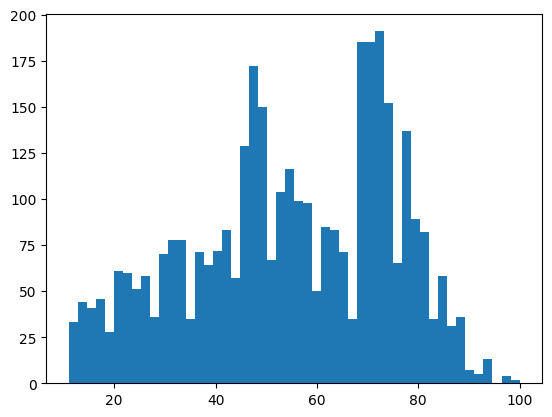

In [30]:
# Распределение таргета
fig = plt.subplot()

fig.hist(train['popularity'], 50)

plt.plot()

Кажется, что есть выбросы со значением 100

In [31]:
train.query('popularity > 95')

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,playlist_subgenre,popularity,year,month,day
844,0.592,157.969,0.521,gaming,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,modern,100,2024,8,16
1502,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,global,100,2024,8,16
1734,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,global,97,2024,5,17
1870,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,mainstream,97,2024,5,17
2097,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,mainstream,98,2024,10,18
2423,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,global,98,2024,10,18


Их совсем немного

У одного трека может быть много исполнителей и комбинации исполнителей редко пересекаются — это может привести к переобучению. Есть гипотеза, что популярность трека больше тяготяет к популярности самого популярного исполнителя. Насколько мне известно, обычно первым пишут как раз самого известного испольнителя

In [32]:
train['track_artist']

0                   Burgundy Skies
1                       Gigi Perez
2                        Yume.Play
3                 Olamilekan Akamo
4                          Dele GT
                   ...            
3618    Dave Koz, Brian Culbertson
3619             Bruce Springsteen
3620        Calvin Harris, Rihanna
3621      Naira Marley, Zinoleesky
3622                       Parcels
Name: track_artist, Length: 3602, dtype: object

In [33]:
train['main_artist'] = train['track_artist'].apply(lambda x: x.split(', ')[0])
test['main_artist'] = test['track_artist'].apply(lambda x: x.split(', ')[0])

In [34]:
train['main_artist']

0          Burgundy Skies
1              Gigi Perez
2               Yume.Play
3        Olamilekan Akamo
4                 Dele GT
              ...        
3618             Dave Koz
3619    Bruce Springsteen
3620        Calvin Harris
3621         Naira Marley
3622              Parcels
Name: main_artist, Length: 3602, dtype: object

Кажется, что количество исполнителей может влиять на популярность

In [35]:
train['num_artists'] = train['track_artist'].apply(lambda x: len(x.split(', ')))
test['num_artists'] = test['track_artist'].apply(lambda x: len(x.split(', ')))

# **Решающее дерево**

Реализовал дерево — с обработкой категориальных фичей через сортировку по среднему значению таргета. Ещё я создал суррогатный спринт для признаков, у которых могут быть неизвестные значения в test: track_album_id, main_artist. 

Оптимизация для выбора оптимального сплита: дисперсия дочерних вершин ищется не за О(n²), а за О(n*log(n)).

Хотел реализовать прунинг, но, насколько мне известно, в случайном лесе мы хотим максимально переобученные деревья — прунинг будет ломать идею, — а в бустинге мы и так хотим максимально простые деревья, которые не нужно прунить (ради «звёздочки» не хватило времени реализовать).

In [36]:
class DecisionTreeRegressor:
    
    def __init__(self, feature_types, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=None, ccp_alpha=0.0, random_state=None):
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self._max_features = max_features
        self._ccp_alpha = ccp_alpha
        self._random_state = random_state
        self._tree = {}
        self._feature_types = feature_types
        self._rng=np.random

    
    def _pruning(self):
        pass


    def _best_split_for_feature(self, X, y, feature):

        if self._feature_types[feature] == 'object' or self._feature_types[feature] == 'object_unknown':
            order = np.unique(np.array(X)[:, feature])[np.argsort(np.array([y[X[:, feature] == i].mean()
                for i in np.unique(X[:, feature])]))]
            sort_mask = np.argsort(np.array([order.tolist().index(x) for x in X[:, feature]])) # в ML хендбуке от Яндекса читал, что так оптимальный сплит находится для категориальных
            split_values = set()
        
        else:
            sort_mask = np.argsort(X[:, feature])
        
        cur_X = X[sort_mask][:, feature]
        cur_y = y[sort_mask]

        elem_sum = np.sum(cur_y)
        sum_squares = np.sum(cur_y ** 2)
        parent_var = np.var(cur_y)

        cur_elem_sum = np.sum(cur_y[:self._min_samples_leaf])
        cur_sum_squares = np.sum(cur_y[:self._min_samples_leaf]**2)

        best_information_gain = 0
        best_split = set() if self._feature_types[feature] == 'object' or self._feature_types[feature] == 'object_unknown' else None
        
        for i in np.arange(self._min_samples_leaf, cur_X.shape[0] - self._min_samples_leaf):

            if cur_X[i] != cur_X[i+1]: 
                
                if self._feature_types[feature] == 'object' or self._feature_types[feature] == 'object_unknown':
                    split_values.add(cur_X[i])
                
                var_left = cur_sum_squares/i - (cur_elem_sum ** 2)/i**2 # итеративно пересчитываю дисперсию, чтобы было за O(n logn), а не O(n^2)
                var_right = (sum_squares - cur_sum_squares)/(cur_X.shape[0] - i) - ((elem_sum - cur_elem_sum) ** 2)/(cur_X.shape[0] - i)**2
                impurity = var_left * i / cur_X.shape[0] + var_right * (cur_X.shape[0] - i) / cur_X.shape[0]
                
                if parent_var - impurity > best_information_gain:
                    best_information_gain = parent_var - impurity                    
                    best_split = best_split | split_values if self._feature_types[feature] == 'object' or self._feature_types[feature] == 'object_unknown' else cur_X[i]

            cur_elem_sum += cur_y[i]
            cur_sum_squares += cur_y[i]**2
        
        if best_information_gain != 0:
            return best_information_gain, best_split, feature
        
    
    def _build_tree(self, X, y, cur_depth, except_features=[], used_unknown=set()): #except_features и used_unknown нужны для эффективной обработки признаков с потенциально неизвестными значениями в test

        features = self._rng.choice(np.delete(np.arange(X.shape[1]), except_features), self._max_features-len(except_features), replace=False)
        
        cur_node = {'cur_feature': None, 'feature_type': None, 'split_value': None, 'prediction': y.mean(), 'children': [], 'is_leaf': True}
        children = []
        
        if X.shape[0] < self._min_samples_split or (self._max_depth is not None and cur_depth == self._max_depth):
            return cur_node

        splits = []
        for feature in features:
            bs = self._best_split_for_feature(X, y, feature)
            if bs is not None:
                splits.append(bs)

        if len(splits) > 0:
            best_split = max(splits, key=lambda x: x[0])
            best_feature = best_split[2]
            best_feature_type = self._feature_types[best_feature]
            best_split_value = best_split[1]
            is_leaf = False
            
            left = np.isin(X[:, best_feature], list(best_split_value), assume_unique=True) if best_feature_type == 'object' \
                or best_feature_type == 'object_unknown' else X[:, best_feature] <= best_split_value
            right = ~np.isin(X[:, best_feature], list(best_split_value), assume_unique=True) if best_feature_type == 'object' \
                or best_feature_type == 'object_unknown' else X[:, best_feature] > best_split_value
            
            children.extend([[X[left], y[left]], [X[right], y[right]]])
        
            cur_node = {
                'cur_feature': best_feature,
                'feature_type': best_feature_type,
                'split_value': best_split_value, 
                'prediction': y.mean(), 
                'is_leaf': is_leaf,
                'children': []
            }

            if best_feature_type == 'object_unknown' and best_feature not in used_unknown:
                cur_node['values_pool'] = set(X[:, best_feature])
                children.append([X, y])
                used_unknown.add(best_feature)

        for child in range(len(children)):
            if child == 2:
                cur_node['children'].append(self._build_tree(*children[child], cur_depth+1, except_features + [best_feature], set()))
            else:
                cur_node['children'].append(self._build_tree(*children[child], cur_depth+1, except_features, used_unknown))
                
        return cur_node
        

    def fit(self, X, y):
        self._tree.clear()
        
        if self._max_features is None:
            self._max_features = X.shape[1]

        if self._random_state is not None:
            self._rng = np.random.RandomState(self._random_state)

        if self._feature_types is None:
            self._feature_types = np.array(['float64'] * X.shape[1])
            
        self._tree = self._build_tree(X, y, cur_depth=0, except_features=[], used_unknown=set())

        if self._ccp_alpha != 0:
            self._pruning()

        return self

    def _predict_single_value(self, X):
        cur_node = self._tree
        while not cur_node['is_leaf']:
            if cur_node['feature_type'] == 'object' or cur_node['feature_type'] == 'object_unknown':
                if cur_node['feature_type'] == 'object_unknown' and 'values_pool' in cur_node and not X[cur_node['cur_feature']][0] in cur_node['values_pool']:
                    cur_node = cur_node['children'][2]
                else:
                    if np.isin(X[cur_node['cur_feature']], list(cur_node['split_value']), assume_unique=True):
                        cur_node = cur_node['children'][0]
                    else:
                        cur_node = cur_node['children'][1]
            else:
                cur_node = cur_node['children'][0] if X[cur_node['cur_feature']] <= cur_node['split_value'] else cur_node['children'][1]
        return cur_node['prediction']
    
    def predict(self, X):
        return np.array([self._predict_single_value(x) for x in X])

Базовая метрика rmse

In [37]:
def rmse(y_pred, y_true):
    return np.sqrt(np.sum((y_pred - y_true)**2)/y_pred.shape[0])

In [38]:
#tree = DecisionTreeRegressor(feature_types=train.drop(['popularity', 'track_album_release_date', 'track_name', 'playlist_name', 'track_artist', 'track_album_name', 'playlist_subgenre', 'playlist_genre'], axis=1).dtypes.values)

In [39]:
#tree.fit(np.array(train.drop(['popularity', 'track_album_release_date', 'track_name', 'playlist_name', 'track_artist', 'track_album_name', 'playlist_subgenre', 'playlist_genre'], axis=1)), np.array(train['popularity']))

In [40]:
#y_pred = tree.predict(np.array(train.drop(['popularity', 'track_album_release_date', 'track_name', 'playlist_name', 'track_artist', 'track_album_name', 'playlist_subgenre', 'playlist_genre'], axis=1)))

In [41]:
#rmse(y_pred, train['popularity'])

In [42]:
#y_test_pred = tree.predict(np.array(test.drop(['track_album_release_date', 'track_name', 'playlist_name', 'track_artist', 'track_album_name', 'playlist_subgenre', 'playlist_genre'], axis=1)))

In [43]:
#pd.DataFrame(index=test.index, data=y_test_pred, columns=['popularity']).to_csv('submission.csv', index_label='Id')

**public score 19.8**

# **Random Forest**

Классическая реализация «случайного леса» с бутстрапированием подвыборок для каждого леса и выбором d/3 признаков для каждого сплита. 

In [44]:
class RandomForestRegressor:

    def __init__(
        self, 
        base_estimator, 
        n_estimators=100,
        random_state=0
    ):

        self._base_estimator = base_estimator
        self._n_estimators = n_estimators
        self._random_state = random_state
        self._estimators = []
        self._rng = np.random


    def fit(self, X, y):

        self._estimators.clear()
        if self._random_state is not None:
            self._rng = np.random.RandomState(self._random_state)
        

        for i in tqdm(range(self._n_estimators)):
            
            choice_mask = self._rng.choice(np.arange(X.shape[0]), X.shape[0], replace=True)
            cur_X = X[choice_mask]
            cur_y = y[choice_mask]
            seed = self._rng.randint(0, 1000000)
            tree = self._base_estimator(seed)
            tree.fit(X, y)
            self._estimators.append(tree)

    def predict(self, X):

        predictions = np.array(list(tqdm(map(lambda model: model.predict(X), self._estimators), total=len(self._estimators))))
        return np.mean(predictions, axis=0)
        

Стандартный permutation_feature_importance

In [45]:
def permutation_feature_importance(train, target, model, check_cols, random_state=0):
    
    new_train, val = train_test_split(train, train_size=0.8, stratify=train[target], random_state=random_state)

    model.fit(np.array(new_train.drop(target, axis=1)), np.array(new_train[target]))
    print(f'val скор без перестановок: {rmse(model.predict(np.array(val.drop(target, axis=1))), np.array(val[target]))}')
    rng = np.random.RandomState(random_state)
    
    for column in check_cols:
        cur_col = new_train[column].copy()
        cur_shuffled_col = rng.choice(new_train.index, new_train.index.shape[0], replace=False)
        new_train.loc[:, column] = list(new_train[column].loc[cur_shuffled_col])
        model.fit(np.array(new_train.drop(target, axis=1)), np.array(new_train[target]))
        print(f'val скор с рандомной {column}: {rmse(model.predict(np.array(val.drop(target, axis=1))), np.array(val[target]))}')
        new_train[column] = cur_col

In [46]:
# %%time
# rf.fit(np.array(train.drop(['popularity', 'track_name'], axis=1)), np.array(train['popularity']))

Заменю тип категориальных данных на object, чтобы их обработать внутри дерева как категориальные

In [47]:
train[['playlist_genre', 'time_signature', 'playlist_name', 'mode', 'key', 'playlist_subgenre', 'year', 'month', 'day']] = train[['playlist_genre', 'time_signature', 'playlist_name', 'mode', 'key', 'playlist_subgenre', 'year', 'month', 'day']].astype('object')

Сделаю значения для признаков main_artist и track_album_id типом с обработкой неизвестных значений в train: очевидно, что в тесте многих не будет, чего не скажешь о других категориях.

In [48]:
feature_dtypes = train.drop(['popularity', 'track_name', 'track_id', 'track_artist'], axis=1).dtypes.values
feature_dtypes[train.drop(['popularity', 'track_name', 'track_id', 'track_artist'], axis=1).dtypes.index.get_loc('main_artist')] = 'object_unknown'
feature_dtypes[train.drop(['popularity', 'track_name', 'track_id', 'track_artist'], axis=1).dtypes.index.get_loc('track_album_id')] = 'object_unknown'

Проверю признаки main_artist и track_album_id, потому что они могут вести только к оверфиту из-за количества вариантов

In [49]:
# permutation_check = RandomForestRegressor(base_estimator=lambda seed: DecisionTreeRegressor(feature_types=feature_dtypes, random_state=seed, max_features=int(np.round(train.shape[1]/3)), min_samples_leaf=5, max_depth=10), n_estimators=10)
# check_cols = ['duration_ms', 'day', 'main_artist', 'track_album_id']
# permutation_feature_importance(train.drop(['track_name', 'track_id', 'track_artist'], axis=1), target='popularity', model=permutation_check, check_cols=check_cols, random_state=0)

Кажется, что способ проверки не очень сработал тк нет времени строить полные леса

In [50]:
drop_cols = [
    'popularity', 
    'track_name',
    'track_id',
    'track_artist',
     ]

In [51]:
tttrain, val = train_test_split(train, train_size=0.8, stratify=train['popularity'], random_state=3)

In [52]:
# tttrain, val = ordered_target_encoding(tttrain, val, ['track_album_id', 'main_artist'], 'popularity', 10)

In [53]:
feature_dtypes = tttrain.drop(drop_cols, axis=1).dtypes.values
# feature_dtypes[train.drop(drop_cols, axis=1).dtypes.index.get_loc('main_artist')] = 'object_unknown'

In [54]:
rf = RandomForestRegressor(base_estimator=lambda seed: DecisionTreeRegressor(feature_types=feature_dtypes, random_state=seed, max_features=int(np.round(feature_dtypes.shape[0]/3))+1, min_samples_leaf=5, max_depth=15), n_estimators=150)

In [55]:
# rf.fit(np.array(tttrain.drop(drop_cols, axis=1)), np.array(tttrain['popularity']))

In [56]:
# preds = rf.predict(np.array(val.drop(drop_cols, axis=1)))

In [57]:
# rmse(preds, val['popularity'])

У нас целочисленные таргеты, и треки с одинаковым id имеют одинаковый таргет. Попробую это учесть, и, может быть, скор улучшится.

In [58]:
# unique_tracks = np.unique(val['track_id'])
# for track in unique_tracks:
#     mask = np.array(val['track_id']) == track
#     mean_val = preds[mask].mean()
#     preds[mask] = mean_val

In [59]:
# rmse(preds, val['popularity'])

In [60]:
# preds = np.round(preds)

In [61]:
# rmse(preds, val['popularity'])

Что-то выиграть удалось, округлять не буду

In [62]:
# train, test = ordered_target_encoding(train, test, ['track_album_id', 'main_artist'], 'popularity', 10)

In [63]:
rf = RandomForestRegressor(base_estimator=lambda seed: DecisionTreeRegressor(feature_types=feature_dtypes, random_state=seed, max_features=int(np.round(feature_dtypes.shape[0]/3))+1, min_samples_leaf=5, max_depth=15), n_estimators=150)

In [64]:
# rf.fit(np.array(train.drop(drop_cols, axis=1)), np.array(train['popularity']))

In [65]:
# drop_cols.remove('popularity')
# y_test_pred = rf.predict(np.array(test.drop(drop_cols, axis=1)))
# drop_cols.append('popularity')

In [66]:
# unique_tracks = np.unique(test['track_id'])
# for track in unique_tracks:
#     mask = np.array(test['track_id']) == track
#     mean_val = y_test_pred[mask].mean()
#     y_test_pred[mask] = mean_val

In [67]:
# y_test_pred = np.round(y_test_pred)

In [68]:
# pd.DataFrame(index=test.index, data=y_test_pred, columns=['popularity']).to_csv('submission.csv', index_label='Id')

**public score 10.5**

# **CatBoost**

Симметричное забывчивое дерево. На каждом этаже дерева выбирается один и тот же сплит. Прогноз в листе собирается упорядоченным образом, в качестве прогноза считается среднее значение таргета в листе до текущего элемента. Качество сплита определяется по косинусной мере между прогнозом и таргетом.

Получилось реализовать супербыстрый предикт через битовые операции, но фит так реализовать не получилось, потому что я не додумался. Итого: для фита нет выигрыша по времени :(

Пробовал в итоговой реализации — бустинг вообще не переобучался. Однако качество на валидации выходило на плато с цифрой выше, чем при предыдущей реализации дерева :(

In [69]:
class CatBoostTreeRegressor:
    def __init__(self, max_depth=3, num_bins_for_split=10):
        self._max_depth = max_depth
        self._num_bins_for_split = num_bins_for_split
        self._splitters = np.array([], dtype=int)
        self._split_values = np.array([], dtype=float)
        self._leaf_values = np.array([], dtype=float)

    
    def _coisine_similarity(self, y, preds):
        return np.dot(y, preds)/(np.linalg.norm(y)*np.linalg.norm(preds))

    
    def _split_for_feature(self, X, y, threshold):

        left_sum = left_cnt = right_sum = right_cnt = 0
        preds = np.empty_like(y, dtype=float)
    
        for i in range(X.shape[0]):
            if X[i] < threshold:                 
                preds[i] = y.mean() if left_cnt == 0 else left_sum / left_cnt
                left_sum += y[i];  left_cnt += 1
            else:                                
                preds[i] = y.mean() if right_cnt == 0 else right_sum / right_cnt
                right_sum += y[i]; right_cnt += 1
        return preds

    
    def fit(self, X, y):
        
        self._splitters = np.array([], dtype=int)
        self._split_values = np.array([], dtype=float)
        self._predictions = np.array([], dtype=float)
            
        for cur_depth in  np.arange(self._max_depth):
            branches = self._predict_branch(X)
            best_cos = -np.inf
            best_feature = None
            best_threshold = None
            
            for feature in np.arange(X.shape[1]):
                
                thresholds = np.quantile(X[:, feature], np.linspace(0, 1, self._num_bins_for_split + 2)[1:-1])
                
                for threshold in thresholds:
                    cur_preds = np.zeros_like(y, dtype=float)

                    for branch in range(2 ** cur_depth):
                        new_preds = self._split_for_feature(X[:, feature][branches == branch], y[branches == branch], threshold)
                        cur_preds[branches == branch] = new_preds
                    cur_cos = self._coisine_similarity(y, cur_preds)

                    if cur_cos > best_cos:
                        best_cos = cur_cos
                        best_feature = feature
                        best_threshold = threshold

            self._splitters = np.append(self._splitters, best_feature)
            self._split_values = np.append(self._split_values, best_threshold)


        leaf_idx = self._predict_branch(X)
        n_leaves = 1 << self._max_depth
        self._leaf_values = np.zeros(n_leaves)
    
        for idx in np.unique(leaf_idx):
            self._leaf_values[idx] = y[leaf_idx == idx].mean()
        return self
        
    
    def _predict_branch(self, X):
        if self._splitters.size == 0:
            return np.zeros(X.shape[0], dtype=np.uint32)
        
        decision_cols = X[:, self._splitters]
        bit_array = (decision_cols >= self._split_values).astype(np.uint8)
        weights = 1 << np.arange(bit_array.shape[1] - 1, -1, -1, dtype=np.uint32)
        return bit_array.dot(weights)

    def predict(self, X):
        return self._leaf_values[self._predict_branch(X)]

Версия CatBoost, в которой категориальные фичи кодируются с помощью order target encoding. При этом для каждого дерева объекты перемешиваются, чтобы ещё больше уменьшить переобучение.

Градиент считал по mse, так как это проще, и у него такой же минимум, как у rmse. 

In [70]:
class CatBoostRegressor:
    def __init__(
        self, 
        base_estimator=lambda: CatBoostTreeRegressor(max_depth=4),
        n_estimators=100,
        learning_rate=0.1,
        random_state=0
    ):

        self._base_estimator = base_estimator
        self._n_estimators = n_estimators
        self._learning_rate = learning_rate
        self._random_state = random_state
        self._estimators = []
        self._rng = np.random
        self._best_iteration = -1

    def _ordered_target_encoding(self, X, y, cat_features, smoothing):
        global_mean = y.mean()
        new_X = X.copy()
        new_X = new_X.astype('object')
        
        for feature in cat_features:
            target_cat_sum = {}
            cur_X_column = []
    
            for i in range(new_X[:, feature].shape[0]):
                
                if new_X[:, feature][i] not in target_cat_sum:
                    target_cat_sum[new_X[:, feature][i]] = [0, 0]
                
                cur_X_column.append((smoothing * global_mean + target_cat_sum[new_X[:, feature][i]][0])/(smoothing + target_cat_sum[new_X[:, feature][i]][1]))
    
                target_cat_sum[new_X[:, feature][i]][0] += y[i]
                target_cat_sum[new_X[:, feature][i]][1] += 1
    
            new_X[:, feature] = np.array(cur_X_column)
            
        # new_X = new_X.astype('float64')
        return new_X
    

    def fit(self, X, y, X_val, y_val, categorical_features):

        self._estimators.clear()
        if self._random_state is not None:
            self._rng = np.random.RandomState(self._random_state)

        cur_predictions = np.zeros_like(y, dtype='float')
        cur_X = X.copy()
        cur_y = y.copy()

        best_val_score = np.inf
        
        for i in tqdm(range(self._n_estimators)):

            choice_mask = self._rng.choice(np.arange(cur_X.shape[0]), cur_X.shape[0], replace=False)
            cur_X = cur_X[choice_mask]
            cur_y = cur_y[choice_mask]
            cur_predictions = cur_predictions[choice_mask]
            
            X_fit = self._ordered_target_encoding(cur_X, cur_y, categorical_features, 10)
            cur_residuals = cur_y - cur_predictions

            seed = self._rng.randint(1, 1000000)
            tree = self._base_estimator(seed)
            tree.fit(X_fit, cur_residuals)
            self._estimators.append(tree)
            cur_predictions += self._learning_rate * tree.predict(X_fit)

            if X_val is not None and y_val is not None:
                if (i+1) % 25 == 0:
                    val_score = rmse(self.predict(X_val), y_val)
                    print(f'val RMSE итерация {i+1}: {val_score}')
                    if val_score < best_val_score:
                        best_val_score = val_score
                        self._best_iteration = i+1


    def predict(self, X, only_best_val_models=False):
        models = self._estimators[:self._best_iteration] if only_best_val_models else self._estimators
        predictions = np.array(list(tqdm(map(lambda model: model.predict(X), models), total=len(models))))
        return np.sum(self._learning_rate * predictions, axis=0)

Эксперимент с новым деревом, val score в среднем 10-10.1

In [71]:
# drop_cols = [
#     'popularity', 
#     'track_name',
#     'track_id',
#     'track_artist',
#      ]

In [72]:
# train['mode'] = train['mode'].astype('float') # бинарный признак
# test['mode'] = test['mode'].astype('float')

In [73]:
# tttrain, val = train_test_split(train, train_size=0.95, stratify=train['popularity'], random_state=20)

In [74]:
# dtypes = tttrain.drop(drop_cols, axis=1).dtypes.reset_index()
# cat_features = dtypes[dtypes[0] == 'object'].index.values

In [75]:
# _, val = ordered_target_encoding(tttrain, val, dtypes.loc[cat_features]['index'], 'popularity', 10)

In [76]:
# cbr = CatBoostRegressor(n_estimators=100, learning_rate=0.1)

In [77]:
# cbr.fit(np.array(tttrain.drop(drop_cols, axis=1)), np.array(tttrain['popularity']), np.array(val.drop(drop_cols, axis=1)), val['popularity'], cat_features)

In [78]:
# rmse(cbr.predict(np.array(val.drop(drop_cols, axis=1))), val['popularity'])

Остался последний сабмит и тут я понял, что у меня была модель со скором 8–9 на валидации, а оказывается у меня в тесте поплыла индексация колонок из-за одной строчки.

In [79]:
train['mode'] = train['mode'].astype('object')
test['mode'] = test['mode'].astype('object')

In [81]:
drop_cols = [
    'popularity', 
    'track_name',
    'track_id',
    'track_artist',
    'duration_ms',
    'day'
     ]

In [89]:
for i in range(10, 60, 10):
    tttrain, val = train_test_split(train, train_size=0.95, stratify=train['popularity'], random_state=i)
    
    feature_dtypes = tttrain.drop(drop_cols, axis=1).dtypes.values
    
    feature_dtypes[tttrain.drop(drop_cols, axis=1).dtypes.index.get_loc('main_artist')] = 'float64'
    feature_dtypes[tttrain.drop(drop_cols, axis=1).dtypes.index.get_loc('track_album_id')] = 'float64'
    
    dtypes = tttrain.drop(drop_cols, axis=1).dtypes.reset_index()
    cat_features = dtypes[(dtypes['index'] == 'main_artist') | (dtypes['index'] == 'track_album_id')].index.values
    
    _, val = ordered_target_encoding(tttrain, val, dtypes.loc[cat_features]['index'], 'popularity', 10)
    
    cbr = CatBoostRegressor(n_estimators=150, base_estimator=lambda seed: DecisionTreeRegressor(feature_dtypes, max_depth=2, random_state=seed), learning_rate=0.05)
    
    cbr.fit(np.array(tttrain.drop(drop_cols, axis=1)), np.array(tttrain['popularity']), np.array(val.drop(drop_cols, axis=1)), val['popularity'], cat_features)
    
    print(rmse(cbr.predict(np.array(val.drop(drop_cols, axis=1))), val['popularity']))

    print('----------------------------------')

In [82]:
drop_cols = [
    'popularity', 
    'track_name',
    'track_id',
    'track_artist',
    'duration_ms',
    'day'
     ]

feature_dtypes = train.drop(drop_cols, axis=1).dtypes.values

feature_dtypes[train.drop(drop_cols, axis=1).dtypes.index.get_loc('main_artist')] = 'float64'
feature_dtypes[train.drop(drop_cols, axis=1).dtypes.index.get_loc('track_album_id')] = 'float64'

dtypes = train.drop(drop_cols, axis=1).dtypes.reset_index()
cat_features = dtypes[(dtypes['index'] == 'main_artist') | (dtypes['index'] == 'track_album_id')].index.values

_, test_encoded = ordered_target_encoding(train, test, dtypes.loc[cat_features]['index'], 'popularity', 10)

cbr = CatBoostRegressor(n_estimators=110, base_estimator=lambda seed: DecisionTreeRegressor(feature_dtypes, max_depth=2, random_state=seed), learning_rate=0.05)

cbr.fit(np.array(train.drop(drop_cols, axis=1)), np.array(train['popularity']), None, None, cat_features)

drop_cols.remove('popularity')
y_test_pred = cbr.predict(np.array(test_encoded.drop(drop_cols, axis=1)))
drop_cols.append('popularity')

unique_tracks = np.unique(test_encoded['track_id'])
for track in unique_tracks:
    mask = np.array(test_encoded['track_id']) == track
    mean_val = y_test_pred[mask].mean()
    y_test_pred[mask] = mean_val

pd.DataFrame(index=test_encoded.index, data=y_test_pred, columns=['popularity']).to_csv('submission.csv', index_label='Id')

  0%|          | 0/110 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

**public score 8.85**

Выводы:

Лучше всего сработала стандартная реализация дерева в совокупности с бустингом.

Фичи main_artist и track_album_id обрабатывались с помощью ordered_target_encoder, а остальные категориальные просто искали сплит по среднему значению таргета при них. 
Также я удалил фичи duration_ms и day так как они засоряли модель.